1. Data Loading

In [207]:
import pandas as pd
import numpy as np

df = pd.read_csv("ClaimDenialInputMultiLabel.csv", low_memory=False)

print(df.shape)
print(df.head())

(1000000, 39)
         Clinic      TPCLIID    LIATPCLIid   ServiceDt  \
0  CLN_13838227  TP_41935074   LTP_1870199  2025-06-22   
1  CLN_13838227  TP_44604858  LTP_82010373  2025-06-29   
2  CLN_13838227  TP_26594858           NaN  2025-07-06   
3  CLN_13838227  TP_95683641   LTP_2144057  2025-07-13   
4  CLN_13838227  TP_90042682  LTP_38875939  2025-07-20   

                      Service    ClaimID  AmountCharged CPTCode      ClientID  \
0  Methadone Maintenance Week  143008644         297.61   H0020  CLT_85822412   
1  Methadone Maintenance Week  143008720         208.74   H0020  CLT_85822412   
2  Methadone Maintenance Week  143009390         238.49   H0020  CLT_85822412   
3  Methadone Maintenance Week  143008875         245.26   H0020  CLT_85822412   
4  Methadone Maintenance Week  143008961         228.32   H0020  CLT_85822412   

  ClaimBillDate  ... CoIns CltResp Balance MultiFlag  SameDayCli  \
0    2025-04-06  ...   0.0     0.0    0.00         N           0   
1    2025-04-1

2. Removing Data Leakage Columns

In [209]:
leakage_cols = [
    "TotalPaid",
    "TotalAdj",
    "TotalVoid",
    "Balance",
    "CltResp",
    "cliANSI1",
    "cliANSI2",
    "lastActDt"
]

df = df.drop(columns=leakage_cols)

3. Converting Date Columns

In [211]:
date_cols = ["ServiceDt", "ClaimBillDate", "f11insdob"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

4. Removing Identifier Columns

In [213]:
id_cols = ["TPCLIID", "LIATPCLIid", "ClaimID", "ClientID"]

df = df.drop(columns=id_cols)

5. Converting Numeric Columns

In [215]:
numeric_cols = [
    "AmountCharged",
    "CoPay",
    "Deduc",
    "CoIns",
    "DaysBetServiceToBilling"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

6. Cleaning Binary Target (DenialFlag)

In [217]:

print(df["DenialFlag"].isna().sum())


df = df.dropna(subset=["DenialFlag"])


df["DenialFlag"] = df["DenialFlag"].astype(int)

73985


7. Cleaning Multi-Class Target (MultiFlag)

In [219]:
df["MultiFlag"].value_counts(dropna=False)

MultiFlag
N    764565
P     97757
Z     48946
F     14747
Name: count, dtype: int64

In [220]:
df_multiflag = df.dropna(subset=["MultiFlag"])

8. Preparing Multi-Label Targets

In [222]:
targets = ["target1","target2","target3","target4"]

df[targets].isna().sum()

target1    704425
target2    891924
target3    922141
target4    925029
dtype: int64

In [223]:
df[targets] = df[targets].fillna("None")

9. Encoding Multi-Label Targets (Multi-Hot Encoding)

In [225]:
from sklearn.preprocessing import MultiLabelBinarizer

targets = ["target1", "target2", "target3", "target4"]


df["labels"] = df[targets].apply(
    lambda row: [str(int(x)) for x in row if x != "None" and pd.notna(x)],
    axis=1
)

mlb = MultiLabelBinarizer()

y_multilabel = mlb.fit_transform(df["labels"])

print(y_multilabel.shape)

(926015, 26)


10. Preparing Feature Matrix (X) and Targets (y)

In [227]:
target_cols = ["DenialFlag", "MultiFlag", "target1", "target2", "target3", "target4"]

10.1 Binary Model Dataset (Denial Prediction)

In [230]:
X_binary = df.drop(columns=target_cols + ["labels"])
y_binary = df["DenialFlag"]

print(X_binary.shape, y_binary.shape)

(926015, 21) (926015,)


10.2 Multi-Class Model Dataset (Denial Type)

In [241]:
df_multiflag = df.dropna(subset=["MultiFlag"]).copy()

X_multi = df_multiflag.drop(columns=target_cols + ["labels"])
y_multi = df_multiflag["MultiFlag"]

print(X_multi.shape, y_multi.shape)

(926015, 21) (926015,)


10.3 Multi-Label Model Dataset (Denial Reasons)

In [243]:
X_ml = df.drop(columns=target_cols + ["labels"])
y_ml = y_multilabel

print(X_ml.shape, y_ml.shape)

(926015, 21) (926015, 26)


In [244]:
print("Binary:", X_binary.shape, y_binary.shape)
print("Multi-class:", X_multi.shape, y_multi.shape)
print("Multi-label:", X_ml.shape, y_ml.shape)

Binary: (926015, 21) (926015,)
Multi-class: (926015, 21) (926015,)
Multi-label: (926015, 21) (926015, 26)


11. Identifying Categorical Columns

In [246]:
cat_cols = X_binary.select_dtypes(include="object").columns
print(cat_cols)

Index(['Clinic', 'Service', 'CPTCode', 'Payer', 'Provider',
       'BillingProviderNPI', 'ClaimFacilityNPI', 'eligStatus',
       'tpcliStrModifier', 'f21diag1'],
      dtype='object')


11.2 Frequency Encoding for Categorical Features

In [248]:
def frequency_encode(df, cols):
    df_encoded = df.copy()
    
    for col in cols:
        freq = df_encoded[col].value_counts(normalize=True)
        df_encoded[col] = df_encoded[col].map(freq)
    
    return df_encoded


X_binary_enc = frequency_encode(X_binary, cat_cols)
X_multi_enc = frequency_encode(X_multi, cat_cols)
X_ml_enc = frequency_encode(X_ml, cat_cols)

11.3 Check for Remaining Non-Numeric Columns

In [251]:
print(X_binary_enc.select_dtypes(include="object").columns)

Index([], dtype='object')


11.4 Converting Date Columns to Numeric Features

In [254]:
def process_dates(df):
    df = df.copy()
    
    
    df["service_year"] = df["ServiceDt"].dt.year
    df["service_month"] = df["ServiceDt"].dt.month
    
    df["billing_year"] = df["ClaimBillDate"].dt.year
    df["billing_month"] = df["ClaimBillDate"].dt.month
    

    df["patient_age"] = (df["ServiceDt"] - df["f11insdob"]).dt.days / 365
    
    
    df = df.drop(columns=["ServiceDt", "ClaimBillDate", "f11insdob"])
    
    return df

11.5 Apply Date Processing

In [257]:
X_binary_enc = process_dates(X_binary_enc)
X_multi_enc = process_dates(X_multi_enc)
X_ml_enc = process_dates(X_ml_enc)

11.6 Final Data Type Check

In [259]:
print(X_binary_enc.dtypes)

Clinic                     float64
Service                    float64
AmountCharged              float64
CPTCode                    float64
Payer                      float64
Provider                   float64
BillingProviderNPI         float64
ClaimFacilityNPI           float64
AuthStatus                 float64
eligStatus                 float64
CoPay                      float64
Deduc                      float64
CoIns                      float64
SameDayCli                   int64
DaysBetServiceToBilling      int64
tpcliStrModifier           float64
tpcliStrPOS                  int64
f21diag1                   float64
service_year                 int32
service_month                int32
billing_year                 int32
billing_month                int32
patient_age                float64
dtype: object


12. Train-Test Split (Binary Model)

In [265]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_binary_enc, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

13. Training Baseline Random Forest Model

In [267]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


14. Evaluating Binary Model

In [269]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98    152913
           1       0.94      0.89      0.91     32290

    accuracy                           0.97    185203
   macro avg       0.96      0.94      0.95    185203
weighted avg       0.97      0.97      0.97    185203

ROC-AUC: 0.9857878942115784


15. Threshold Tuning for High Recall

In [277]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    152913
           1       0.88      0.92      0.90     32290

    accuracy                           0.97    185203
   macro avg       0.93      0.95      0.94    185203
weighted avg       0.97      0.97      0.97    185203


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    152913
           1       0.91      0.91      0.91     32290

    accuracy                           0.97    185203
   macro avg       0.95      0.94      0.95    185203
weighted avg       0.97      0.97      0.97    185203


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    152913
           1       0.94      0.89      0.91     32290

    accuracy                           0.97    185203
   macro avg       0.96      0.94      0.95    185203
weighted avg       0.97   

15. Final Predictions with Selected Threshold

In [279]:
best_threshold = 0.3

y_pred_final = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98    152913
           1       0.88      0.92      0.90     32290

    accuracy                           0.97    185203
   macro avg       0.93      0.95      0.94    185203
weighted avg       0.97      0.97      0.97    185203



Since the goal of the binary model is to act as a high-recall filter, I selected a threshold of 0.3, which improves recall for denied claims from 0.89 to 0.92. This ensures fewer denied claims are missed, even at the cost of a slight reduction in precision.

Payer                      0.249562
AmountCharged              0.149287
service_month              0.077343
Provider                   0.076578
Service                    0.065542
Clinic                     0.052356
DaysBetServiceToBilling    0.050990
tpcliStrPOS                0.046400
CPTCode                    0.044529
ClaimFacilityNPI           0.039981
dtype: float64


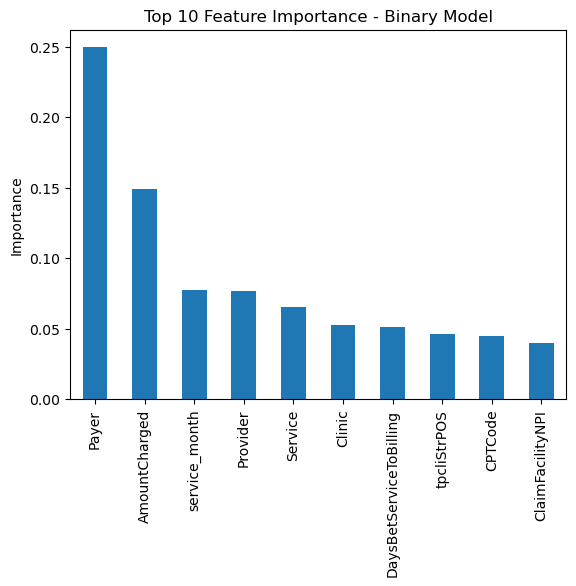

In [283]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = model.feature_importances_

# Convert to DataFrame
feat_imp_binary = pd.Series(importances, index=X_binary_enc.columns)

# Sort
feat_imp_binary = feat_imp_binary.sort_values(ascending=False)

# Print top features
print(feat_imp_binary.head(10))

# Plot
plt.figure()
feat_imp_binary.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance - Binary Model")
plt.ylabel("Importance")
plt.show()

16. MultiFlag Class Distribution Analysis

In [78]:
print(y_multi.value_counts())
print(y_multi.value_counts(normalize=True))

MultiFlag
N    764565
P     97757
Z     48946
F     14747
Name: count, dtype: int64
MultiFlag
N    0.825651
P    0.105567
Z    0.052857
F    0.015925
Name: proportion, dtype: float64


17. Encoding MultiFlag Labels

In [80]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print(le.classes_)

['F' 'N' 'P' 'Z']


18. Train-Test Split (MultiFlag)

In [82]:
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi_enc, y_multi_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_enc
)

19. Random Forest Model (MultiFlag)

In [84]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_m, y_train_m)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


20. Evaluation - Random Forest

In [86]:
from sklearn.metrics import classification_report

y_pred_rf = rf_model.predict(X_test_m)

print(classification_report(y_test_m, y_pred_rf, target_names=le.classes_))


              precision    recall  f1-score   support

           F       0.84      0.66      0.74      2949
           N       0.98      0.99      0.98    152913
           P       0.93      0.94      0.93     19552
           Z       0.78      0.65      0.71      9789

    accuracy                           0.96    185203
   macro avg       0.88      0.81      0.84    185203
weighted avg       0.96      0.96      0.96    185203



21. Confusion Matrix Analysis

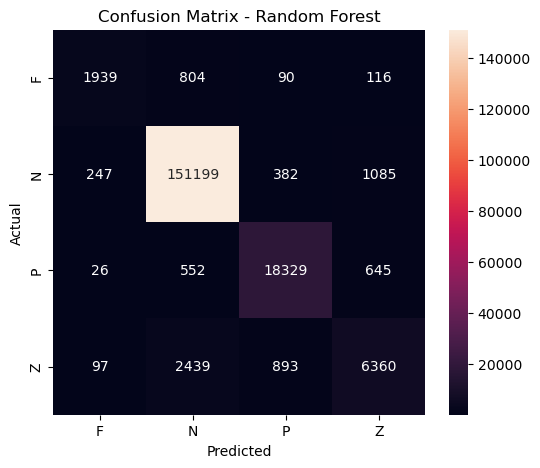

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_m, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

The confusion matrix shows that minority classes such as F and Z are frequently misclassified as the majority class N, indicating class imbalance affecting recall.

Manual Class Weights

In [91]:
from sklearn.model_selection import train_test_split

X_train_multi, X_test_multi, y_train_multi_enc, y_test_multi_enc = train_test_split(
    X_multi_enc,
    y_multi_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_enc
)

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# IMPORTANT: check label mapping
print("Classes:", le.classes_)

# Example mapping (adjust if different):
# F → 0, N → 1, P → 2, Z → 3

class_weights = {
    0: 6,   # F (boost strongly)
    1: 1,   # N
    2: 2,   # P
    3: 4    # Z
}

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights
)

rf_model.fit(X_train_multi, y_train_multi_enc)

# Predictions
y_pred = rf_model.predict(X_test_multi)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test_multi_enc, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi_enc, y_pred))

Classes: ['F' 'N' 'P' 'Z']

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.66      0.73      2949
           1       0.98      0.99      0.98    152913
           2       0.93      0.94      0.93     19552
           3       0.77      0.65      0.71      9789

    accuracy                           0.96    185203
   macro avg       0.88      0.81      0.84    185203
weighted avg       0.96      0.96      0.96    185203


Confusion Matrix:
[[  1942    799     85    123]
 [   258 151161    372   1122]
 [    23    543  18330    656]
 [   113   2414    883   6379]]


22. XGBoost Model (MultiFlag)

In [94]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    use_label_encoder=False
)

xgb_model.fit(X_train_m, y_train_m)

C:\Users\aksha\New_folder\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:02:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


23. Evaluation - XGBoost

In [96]:
y_pred_xgb = xgb_model.predict(X_test_m)

print(classification_report(y_test_m, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

           F       0.87      0.47      0.61      2949
           N       0.96      0.99      0.97    152913
           P       0.89      0.94      0.92     19552
           Z       0.86      0.36      0.50      9789

    accuracy                           0.95    185203
   macro avg       0.89      0.69      0.75    185203
weighted avg       0.94      0.95      0.94    185203



24. Model Comparison

Random Forest outperformed XGBoost across most evaluation metrics, particularly for minority classes. While both models performed well on the majority class (N), XGBoost showed significantly lower recall for full denial (F) and zero-payment (Z) classes.

25. Feature Importance Analysis (Random Forest)

In [169]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_m.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(30))

Payer                      0.203393
AmountCharged              0.173497
service_month              0.092853
Service                    0.065097
DaysBetServiceToBilling    0.065092
Provider                   0.063119
billing_month              0.049211
Clinic                     0.045096
tpcliStrPOS                0.041914
CPTCode                    0.038008
BillingProviderNPI         0.036430
ClaimFacilityNPI           0.035887
SameDayCli                 0.027739
tpcliStrModifier           0.020096
service_year               0.010060
billing_year               0.009764
CoIns                      0.008520
eligStatus                 0.005538
CoPay                      0.004936
Deduc                      0.003750
f21diag1                   0.000000
AuthStatus                 0.000000
patient_age                0.000000
dtype: float64


26. Feature Scaling for Neural Network

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_nn = scaler.fit_transform(X_train_m)
X_test_nn = scaler.transform(X_test_m)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


26.1 Handling Missing Values for Neural Network

In [104]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_nn = imputer.fit_transform(X_train_nn)
X_test_nn = imputer.transform(X_test_nn)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 8 22]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 8 22]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


27. Neural Network (MLP) Model

In [106]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  
    activation='relu',
    solver='adam',
    max_iter=20,   
    random_state=42
)

mlp_model.fit(X_train_nn, y_train_m)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,42


28. Evaluation - Neural Network (MLP)

In [108]:
y_pred_mlp = mlp_model.predict(X_test_nn)

from sklearn.metrics import classification_report
print(classification_report(y_test_m, y_pred_mlp, target_names=le.classes_))

              precision    recall  f1-score   support

           F       0.76      0.42      0.54      2949
           N       0.95      0.98      0.97    152913
           P       0.82      0.89      0.86     19552
           Z       0.72      0.44      0.55      9789

    accuracy                           0.93    185203
   macro avg       0.81      0.68      0.73    185203
weighted avg       0.93      0.93      0.93    185203



Three models were evaluated: Random Forest, XGBoost, and a Neural Network (MLP). Random Forest achieved the best overall performance, particularly in handling minority classes such as full denial (F) and zero-payment (Z).

29. Multi-Label Problem Setup

In [111]:


print(X_ml_enc.shape)
print(y_ml.shape)

print("Number of labels:", y_ml.shape[1])

(926015, 23)
(926015, 26)
Number of labels: 26


30. Train-Test Split (Multi-Label)

In [113]:
from sklearn.model_selection import train_test_split

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml_enc, y_ml,
    test_size=0.2,
    random_state=42
)

In [114]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

br_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
)

br_model.fit(X_train_ml, y_train_ml)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 7 is present in all training examples.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


32. Evaluation - Binary Relevance

In [116]:
from sklearn.metrics import classification_report

y_pred_br = br_model.predict(X_test_ml)

print(classification_report(y_test_ml, y_pred_br))

              precision    recall  f1-score   support

           0       0.74      0.32      0.44       364
           1       0.92      0.88      0.90      1040
           2       0.83      0.48      0.61       310
           3       0.64      0.55      0.59      2753
           4       0.73      0.36      0.49      1267
           5       0.82      0.49      0.61       198
           6       0.81      0.59      0.68        29
           7       0.00      0.00      0.00         1
           8       0.70      0.60      0.64      1491
           9       0.72      0.65      0.68      2409
          10       0.67      0.38      0.49        26
          11       0.86      0.64      0.73       937
          12       0.98      0.92      0.95       113
          13       0.96      0.93      0.95     15103
          14       0.79      0.47      0.59        55
          15       0.91      0.76      0.83      1367
          16       0.92      0.73      0.81       361
          17       1.00    

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\sit

In [117]:
from sklearn.impute import SimpleImputer

imputer_ml = SimpleImputer(strategy="mean")

X_train_ml = imputer_ml.fit_transform(X_train_ml)
X_test_ml = imputer_ml.transform(X_test_ml)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['AuthStatus' 'patient_age']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['AuthStatus' 'patient_age']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [118]:
from sklearn.impute import SimpleImputer


imputer_ml = SimpleImputer(strategy="mean")

X_train_ml = imputer_ml.fit_transform(X_train_ml)
X_test_ml = imputer_ml.transform(X_test_ml)

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

br_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
)

br_model.fit(X_train_ml, y_train_ml)


y_prob_ml = br_model.predict_proba(X_test_ml)

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 7 is present in all training examples.
  warnings.warn(


33. Classifier Chains Model

In [120]:
from sklearn.multioutput import ClassifierChain

cc_model = ClassifierChain(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
)

cc_model.fit(X_train_ml, y_train_ml)

,estimator,RandomForestC...ndom_state=42)
,order,None
,cv,None
,chain_method,'predict'
,random_state,None
,verbose,False
,base_estimator,'deprecated'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


34. Evaluation - Classifier Chains

In [122]:
y_pred_cc = cc_model.predict(X_test_ml)

print(classification_report(y_test_ml, y_pred_cc))

              precision    recall  f1-score   support

           0       0.71      0.35      0.47       364
           1       0.91      0.88      0.89      1040
           2       0.81      0.54      0.65       310
           3       0.64      0.55      0.59      2753
           4       0.68      0.40      0.51      1267
           5       0.85      0.53      0.65       198
           6       0.78      0.62      0.69        29
           7       0.00      0.00      0.00         1
           8       0.71      0.62      0.66      1491
           9       0.72      0.65      0.69      2409
          10       0.71      0.46      0.56        26
          11       0.85      0.64      0.73       937
          12       0.98      0.93      0.95       113
          13       0.97      0.94      0.95     15103
          14       0.79      0.47      0.59        55
          15       0.90      0.78      0.84      1367
          16       0.91      0.74      0.81       361
          17       1.00    

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\sit

35. Multi-Label Metrics

In [124]:
from sklearn.metrics import f1_score

print("Micro F1:", f1_score(y_test_ml, y_pred_cc, average='micro'))
print("Macro F1:", f1_score(y_test_ml, y_pred_cc, average='macro'))
print("Samples F1:", f1_score(y_test_ml, y_pred_cc, average='samples'))

Micro F1: 0.8704714443917102
Macro F1: 0.6749992304500612
Samples F1: 0.20368520976853458


C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


36. Label Co-occurrence Analysis

In [126]:
import pandas as pd

label_df = pd.DataFrame(y_ml, columns=mlb.classes_)

co_matrix = label_df.T.dot(label_df)

print(co_matrix)

       10    11    13     14    15    16   17  18    19      2  ...     3  30  \
10   1901     2    11      4     8    13    5   0    14      9  ...    14   0   
11      2  5296     0    412    25     6    0   0     3     13  ...     2   0   
13     11     0  1496     26     1    10    0   0     7     79  ...     2   0   
14      4   412    26  13605     2    21    0   0   133     82  ...     5   0   
15      8    25     1      2  6388     3    0   0     3     12  ...    10   0   
16     13     6    10     21     3  1035    0   0    20      2  ...     3   0   
17      5     0     0      0     0     0  164   0     0      0  ...     0   0   
18      0     0     0      0     0     0    0   1     0      0  ...     0   0   
19     14     3     7    133     3    20    0   0  7582   3192  ...     2   0   
2       9    13    79     82    12     2    0   0  3192  11874  ...    11   0   
20      0     0     0      0     4     0    0   0     1      4  ...     0   0   
21      1     3   308     19

37. Threshold Tuning (Multi-Label)

In [128]:
y_prob_ml = br_model.predict_proba(X_test_ml)

threshold = 0.3

y_pred_thresh = (y_prob_ml >= threshold).astype(int)

print(classification_report(y_test_ml, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.54      0.53      0.54       364
           1       0.86      0.94      0.90      1040
           2       0.68      0.63      0.66       310
           3       0.58      0.69      0.63      2753
           4       0.55      0.55      0.55      1267
           5       0.70      0.63      0.66       198
           6       0.66      0.66      0.66        29
           7       0.00      0.00      0.00         1
           8       0.63      0.73      0.68      1491
           9       0.67      0.76      0.71      2409
          10       0.62      0.58      0.60        26
          11       0.72      0.72      0.72       937
          12       0.96      0.93      0.95       113
          13       0.93      0.96      0.95     15103
          14       0.74      0.51      0.60        55
          15       0.82      0.84      0.83      1367
          16       0.84      0.80      0.82       361
          17       1.00    

C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aksha\New_folder\Lib\sit

AmountCharged       0.189991
Payer               0.150115
service_year        0.086825
SameDayCli          0.076212
billing_year        0.064744
Provider            0.045951
Service             0.044700
CPTCode             0.032395
tpcliStrModifier    0.028895
Clinic              0.025935
dtype: float64


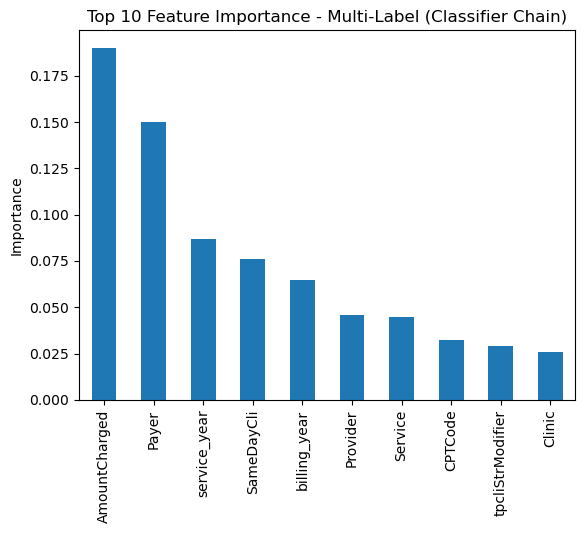

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_features = len(X_ml_enc.columns)  # expected = 21

all_importances = []

for estimator in cc_model.estimators_:
    imp = estimator.feature_importances_

    # Create fixed-size array
    fixed_imp = np.zeros(n_features)

    # Fill only available positions
    length = min(len(imp), n_features)
    fixed_imp[:length] = imp[:length]

    all_importances.append(fixed_imp)

# Convert to array → now shapes match
all_importances = np.array(all_importances)

# Average
mean_importance = np.mean(all_importances, axis=0)

# Convert to Series
feat_imp_ml = pd.Series(mean_importance, index=X_ml_enc.columns)
feat_imp_ml = feat_imp_ml.sort_values(ascending=False)

print(feat_imp_ml.head(10))

# Plot
plt.figure()
feat_imp_ml.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance - Multi-Label (Classifier Chain)")
plt.ylabel("Importance")
plt.show()

### 

In [183]:
import joblib

# Binary
joblib.dump(model, "binary_model.pkl")

# Multi-class
joblib.dump(rf_model, "multiclass_model.pkl")

# ✅ FIX — save CC model
joblib.dump(cc_model, "multilabel_model.pkl")

# Encoders
joblib.dump(le, "label_encoder.pkl")
joblib.dump(mlb, "mlb.pkl")
joblib.dump(imputer_ml, "imputer_ml.pkl")

['imputer_ml.pkl']

In [199]:
print(cc_model.n_features_in_)

21


In [201]:
print(X_ml_enc.columns)

Index(['Clinic', 'Service', 'AmountCharged', 'CPTCode', 'Payer', 'Provider',
       'BillingProviderNPI', 'ClaimFacilityNPI', 'AuthStatus', 'eligStatus',
       'CoPay', 'Deduc', 'CoIns', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'service_year',
       'service_month', 'billing_year', 'billing_month', 'patient_age'],
      dtype='object')


In [203]:
freq_maps = {}

for col in cat_cols:
    freq_maps[col] = X_binary[col].value_counts(normalize=True).to_dict()

joblib.dump(freq_maps, "freq_maps.pkl")

['freq_maps.pkl']